In [1]:
import pickle
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import lonlat_labels as label
import cartopy.crs as ccrs
from plot_boundary import plot_boundaries_folder_on_ax
import pyshtools as pysh
import boule as bl
from add_text_lonlat import add_text_lonlat
from matplotlib.colors import LightSource

pygmt-session [ERROR]: Cannot find the PSL_UTF-8 encoding
begin [ERROR]: Cannot find the PSL_UTF-8 encoding
d:\conda_envs\planet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
topo = pysh.datasets.Moon.LDEM_shape_pa()
topo_grid = topo.expand(grid="DH2", lmax=1200, extend=False)
topo_xr = topo_grid.to_xarray()
topo_xr.values-=bl.Moon2015.mean_radius

In [3]:
PROJECT_ROOT = Path.cwd().parent

最大: 10828.414459813386 @ 201.35720233139054 5.320566194837625
最小: -8478.623430598993 @ 211.02414654454623 -61.4487926727727


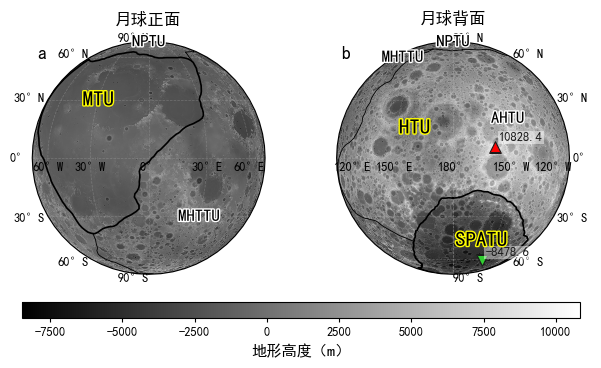

In [4]:
lon=topo_xr['lon'].values
lat=topo_xr['lat'].values
Z=topo_xr.values

# -----------------------------
# Nature-ish + 中文风格（统一）
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "out",
    "ytick.direction": "out",

    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=13, fontweight="bold"
    )

# 色标范围：厚度一般 >=0，建议这样
v = float(np.nanmax(Z))

# -----------------------------
# 图尺寸（论文友好）
# -----------------------------
fig = plt.figure(figsize=(7.2, 3.6))

# ============================
# 正面
# ============================
ax1 = plt.subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=0))
ax1.set_global()

pm1 = ax1.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="gray",
    #vmin=0, vmax=v
)

ax1.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5, alpha=0.35, linestyle="--"
)
ax1.set_title("月球正面", y=1.04)
add_panel_label(ax1, "a")

# ============================
# 背面
# ============================
ax2 = plt.subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
ax2.set_global()

pm2 = ax2.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="gray",
    #vmin=0, vmax=v
)

ax2.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5, alpha=0.35, linestyle="--"
)
ax2.set_title("月球背面", y=1.04)
add_panel_label(ax2, "b")

# -----------------------------
# 色标（更简洁）
# -----------------------------
cbar = fig.colorbar(
    pm1, ax=[ax1, ax2],
    orientation="horizontal",
    pad=0.10, fraction=0.06, aspect=35
)
cbar.set_label("地形高度（m）")
cbar.ax.tick_params(labelsize=9)

# -----------------------------
# 经纬度标签（你原逻辑）
# -----------------------------
xlocs = np.arange(-180, 180, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax1, ylocs, side="left")
label.add_lon_labels_on_equator(ax1, xlocs)

label.add_lat_labels_on_limb(ax2, ylocs, side="right")
label.add_lon_labels_on_equator(ax2, xlocs, central_lonlat=(180, 0))

# -----------------------------
# 极值点（全局最大/最小）
# -----------------------------
mask = np.isfinite(Z)

# 最大
imax = np.nanargmax(np.where(mask, Z, np.nan))
ilat_max, ilon_max = np.unravel_index(imax, Z.shape)
lat_max = float(lat[ilat_max])
lon_max = float(lon[ilon_max])
val_max = float(Z[ilat_max, ilon_max])

# 最小
imin = np.nanargmin(np.where(mask, Z, np.nan))
ilat_min, ilon_min = np.unravel_index(imin, Z.shape)
lat_min = float(lat[ilat_min])
lon_min = float(lon[ilon_min])
val_min = float(Z[ilat_min, ilon_min])

print("最大:", val_max, "@", lon_max, lat_max)
print("最小:", val_min, "@", lon_min, lat_min)

def mark_extreme(ax, lon0, lat0, value, marker, color, text_dx=2.0, text_dy=2.0):
    # 标记点（不那么夸张，更论文）
    ax.scatter(
        [lon0], [lat0],
        transform=ccrs.PlateCarree(),
        s=70,
        marker=marker,
        facecolor=color,
        edgecolor="0.1",
        linewidth=0.8,
        zorder=10
    )

    # 数值标注（稍微偏移，避免压在点上）
    ax.text(
        lon0 + text_dx, lat0 + text_dy,
        f"{value:.1f}",
        transform=ccrs.PlateCarree(),
        fontsize=9,
        ha="left", va="bottom",
        color="0.1",
        bbox=dict(facecolor="white", alpha=0.45, edgecolor="none", pad=0.8),
        zorder=11
    )

# 如果你只想在“对应半球可见处”标记，可以再加可见性判断；
# 这里先按你的需求：两幅图都标出来（即使在背面会不可见/贴边）
mark_extreme(ax1, lon_max, lat_max, val_max, "^", "red")
mark_extreme(ax1, lon_min, lat_min, val_min, "v", "limegreen")
mark_extreme(ax2, lon_max, lat_max, val_max, "^", "red")
mark_extreme(ax2, lon_min, lat_min, val_min, "v", "limegreen")

folder_path="data"
plot_boundaries_folder_on_ax(ax1, folder_path, thick_keywords=("SPATU", "MTU"),linewidth_thick=1.2,linewidth_thin=0.6)
plot_boundaries_folder_on_ax(ax2, folder_path, thick_keywords=("SPATU", "MTU"),linewidth_thick=1.2,linewidth_thin=0.6)


add_text_lonlat(ax1, -30, 30, "MTU", fontsize=15, weight="bold",outline_color="yellow")
add_text_lonlat(ax1, 30, -30, "MHTTU", fontsize=12, weight="bold")
add_text_lonlat(ax1, 0, 90, "NPTU", fontsize=12, weight="bold")

add_text_lonlat(ax2, -160, -45, "SPATU", fontsize=15, weight="bold",outline_color="yellow")
add_text_lonlat(ax2, 160, 15, "HTU", fontsize=15,outline_color="yellow")
add_text_lonlat(ax2, -150, 20, "AHTU", fontsize=12)
add_text_lonlat(ax2, 180, 90, "NPTU", fontsize=12, weight="bold")
add_text_lonlat(ax2, 120, 60, "MHTTU", fontsize=12, weight="bold")

# -----------------------------
# 保存（推荐 png+pdf）
# -----------------------------
fig.savefig(PROJECT_ROOT/"plotting/figure/月球板块划分_正背面", dpi=600, bbox_inches="tight")
#fig.savefig("月球板块划分_正背面_中文_nature风格.pdf", dpi=600, bbox_inches="tight", transparent=True)

plt.show()